# 06_02 - Decision Engine: RL Prototype
## 1. Methodology Overview

This notebook builds and applies the experimental RL policy using the same policy inputs as the heuristic engine.
The implementation is intentionally lightweight (tabular Q-learning) and designed for transparent diagnostics.

**Source data used in this notebook:**
- `data/processed/train_features.csv`
- `data/processed/validation_features.csv`

**Core modules used in this notebook:**
- `src/models/train_model.py`
- `src/decision/policy_inputs.py`
- `src/rl/train_rl_agent.py`
- `src/decision/rl_policy.py`

In [2]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = Path('../../').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

train_df = pd.read_csv(project_root / 'data/processed/train_features.csv')
validation_df = pd.read_csv(project_root / 'data/processed/validation_features.csv')

print(f'Train features: {train_df.shape[0]} rows x {train_df.shape[1]} columns')
print(f'Validation features: {validation_df.shape[0]} rows x {validation_df.shape[1]} columns')
display(validation_df.head())

Train features: 1461 rows x 155 columns
Validation features: 366 rows x 155 columns


,Date,Spot_Price_SPEL,Future_M1_Price,Future_M1_OpenInterest,Future_M2_Price,Future_M2_OpenInterest,Future_M3_Price,Future_M3_OpenInterest,Future_M4_Price,Future_M4_OpenInterest,...,future_m5_oi_change_1d,future_m5_oi_change_7d,future_m5_oi_pct_change_1d,future_m5_oi_pct_change_7d,future_m6_oi_change_1d,future_m6_oi_change_7d,future_m6_oi_pct_change_1d,future_m6_oi_pct_change_7d,front_month_premium,front_month_premium_rel
0,2024-01-01,36.24,76.50,365.0,75.25,355.0,66.00,354.0,57.26,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.26,1.110927
1,2024-01-02,40.91,74.25,355.0,63.50,354.0,55.75,0.0,56.85,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,33.34,0.814960
2,2024-01-03,55.08,76.50,355.0,67.00,354.0,57.29,0.0,58.38,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,21.42,0.388889
3,2024-01-04,91.36,77.00,365.0,68.00,354.0,57.36,0.0,61.50,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,-14.36,-0.157180
4,2024-01-05,68.62,77.50,365.0,69.20,354.0,59.36,0.0,63.50,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,8.88,0.129408


## 2. Prepare Policy Inputs and Train the Q-Learning Agent

The RL agent is trained on policy inputs (forecast + market state) and learns to select one of three actions.
We keep training diagnostics visible to inspect learning quality.

In [3]:
from src.models.train_model import train_quantile_suite
from src.decision.policy_inputs import prepare_policy_inputs
from src.rl.train_rl_agent import train_q_learning_agent

quantile_output = train_quantile_suite(train_df=train_df, eval_df=validation_df)
policy_inputs_df = prepare_policy_inputs(validation_df, quantile_output.results)

rl_training_artifacts = train_q_learning_agent(policy_inputs_df)

display(rl_training_artifacts.rewards_summary_df)
display(rl_training_artifacts.rewards_history_df.tail(10))

print(f'Learned Q-table states: {len(rl_training_artifacts.agent.q_table)}')

2026-04-26 20:07:17 | INFO | src.rl.train_rl_agent | Starting RL training...
2026-04-26 20:07:17 | INFO | src.rl.train_rl_agent | Training dataframe shape: (337, 13)
2026-04-26 20:07:17 | INFO | src.rl.train_rl_agent | Episodes: 1000
2026-04-26 20:07:41 | INFO | src.rl.train_rl_agent | RL training completed successfully.
2026-04-26 20:07:41 | INFO | src.rl.train_rl_agent | Q-table states learned: 268
2026-04-26 20:07:41 | INFO | src.rl.train_rl_agent | Last episode reward: -11309.2550
2026-04-26 20:07:41 | INFO | src.rl.train_rl_agent | Best episode reward: -10969.1050
2026-04-26 20:07:41 | INFO | src.rl.train_rl_agent | Episode steps summary | mean=337.00 | last=337.00
2026-04-26 20:07:41 | INFO | src.rl.train_rl_agent | Reward summary:
   n_episodes   reward_mean   reward_std  reward_min  reward_max  reward_last  \
0        1000 -12859.089095  1467.036814  -19528.695  -10969.105   -11309.255   

   reward_rolling_mean_last_10  steps_mean  steps_last  q_table_states  \
0              

,n_episodes,reward_mean,reward_std,reward_min,reward_max,reward_last,reward_rolling_mean_last_10,steps_mean,steps_last,q_table_states,best_reward
0,1000,-12859.089095,1467.036814,-19528.695,-10969.105,-11309.255,-11223.492,337.0,337.0,268.0,-10969.105


,episode,total_reward,rolling_mean_10
990,991,-11349.825,-11211.4520
991,992,-11292.810,-11222.3710
992,993,-11231.745,-11233.2220
993,994,-11209.620,-11217.8135
994,995,-11067.800,-11206.8210
995,996,-11198.530,-11198.2485
996,997,-11158.110,-11192.3585
997,998,-11348.260,-11216.1720
998,999,-11068.965,-11215.3190
999,1000,-11309.255,-11223.4920


Learned Q-table states: 268


## 3. Apply RL Policy and Inspect Actions

We now generate row-level RL decisions and inspect both the action mix and Q-value diagnostics.

In [4]:
from src.decision.rl_policy import apply_rl_policy

rl_policy_artifacts = apply_rl_policy(
    agent=rl_training_artifacts.agent,
    policy_inputs_df=policy_inputs_df,
    include_q_values=True,
 )

display(rl_policy_artifacts.decisions_df.head(12))
display(rl_policy_artifacts.action_summary_df)

if rl_policy_artifacts.q_values_df is not None:
    display(rl_policy_artifacts.q_values_df.head(12))

2026-04-26 20:07:42 | INFO | src.decision.rl_policy | RL policy applied successfully.
2026-04-26 20:07:42 | INFO | src.decision.rl_policy | Generated RL decisions for 337 rows.
2026-04-26 20:07:42 | INFO | src.decision.rl_policy | Action summary:
  recommended_action  n_days  share_days
0   shift_production     288    0.854599
1         do_nothing      40    0.118694
2      buy_m1_future       9    0.026706


,row_id,action_id,recommended_action,action_source,date
0,0,2,shift_production,rl_policy,2024-01-29
1,1,2,shift_production,rl_policy,2024-01-30
2,2,2,shift_production,rl_policy,2024-01-31
3,3,2,shift_production,rl_policy,2024-02-01
4,4,2,shift_production,rl_policy,2024-02-02
5,5,2,shift_production,rl_policy,2024-02-03
6,6,0,do_nothing,rl_policy,2024-02-04
7,7,2,shift_production,rl_policy,2024-02-05
8,8,0,do_nothing,rl_policy,2024-02-06
9,9,2,shift_production,rl_policy,2024-02-07


,recommended_action,n_days,share_days
0,shift_production,288,0.854599
1,do_nothing,40,0.118694
2,buy_m1_future,9,0.026706


,row_id,date,q_value_action_0,q_value_action_1,q_value_action_2
0,0,2024-01-29,-713.820228,-712.982054,-711.130280
1,1,2024-01-30,-713.405725,-710.039943,-707.855371
2,2,2024-01-31,-730.219633,-712.654646,-699.166994
3,3,2024-02-01,-769.964728,-782.004877,-740.952504
4,4,2024-02-02,-656.991344,-638.739443,-633.290394
5,5,2024-02-03,-592.672023,-605.151586,-582.133156
6,6,2024-02-04,-722.004330,-722.108054,-722.619028
7,7,2024-02-05,-807.510466,-759.911378,-730.950617
8,8,2024-02-06,-477.810671,-467.910531,-467.706595
9,9,2024-02-07,-457.093947,-453.724481,-452.492856


## 4. What the RL Agent Learns

The agent uses **tabular Q-learning** — the simplest form of model-free RL.
It maps (discretized state, action) pairs to expected cumulative reward
and improves this mapping through repeated episodes.

### State space (as of the current implementation)
| Feature | Description |
|---|---|
| `forecast_central` | q50 — central price forecast |
| `forecast_tail` | q90 — upper-tail price forecast |
| `current_m1_future` | Front-month futures price (hedging alternative) |
| `tail_vs_future_abs` | q90 - M1 (the hedge incentive signal) |
| `tail_vs_central_abs` | q90 - q50 (uncertainty spread) |
| `is_weekend` | 1 on weekends (shift flexibility) |
| `is_holiday` | 1 on public holidays |
| `production_level` | Current factory output (0.5 – 1.0) |
| `energy_consumption` | base_load + variable_load * production_level |

### Reward function
```
reward = -total_cost
```
The agent minimises procurement cost by maximising (negative) reward.
Each episode replays the entire validation period; the agent updates
its Q-table after every step using the Bellman equation.

### Action space
Original (backward-compatible): `do_nothing`, `buy_m1_future`, `shift_production`

Extended (optional): `increase_production`, `decrease_production`, `buy_m2_future`, `buy_m3_future`

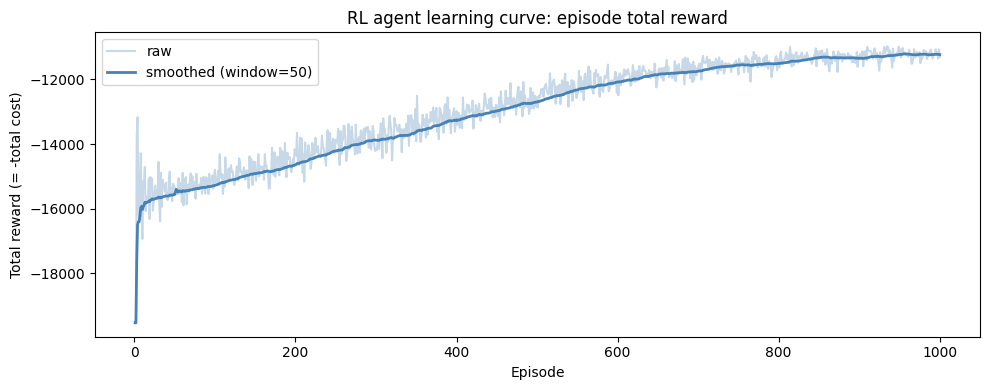


RL training summary:


,n_episodes,reward_mean,reward_std,reward_min,reward_max,reward_last,reward_rolling_mean_last_10,steps_mean,steps_last,q_table_states,best_reward
0,1000,-12859.089095,1467.036814,-19528.695,-10969.105,-11309.255,-11223.492,337.0,337.0,268.0,-10969.105


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Episode reward curve
if hasattr(rl_training_artifacts, 'rewards_history_df') and not rl_training_artifacts.rewards_history_df.empty:
    rewards_hist = rl_training_artifacts.rewards_history_df
    fig, ax = plt.subplots(figsize=(10, 4))

    if 'episode' in rewards_hist.columns and 'total_reward' in rewards_hist.columns:
        # Rolling mean for smoothing
        window = max(1, len(rewards_hist) // 20)
        smoothed = rewards_hist['total_reward'].rolling(window, min_periods=1).mean()
        ax.plot(rewards_hist['episode'], rewards_hist['total_reward'],
                alpha=0.3, color='steelblue', label='raw')
        ax.plot(rewards_hist['episode'], smoothed,
                color='steelblue', lw=2, label=f'smoothed (window={window})')
        ax.set_title('RL agent learning curve: episode total reward')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Total reward (= -total cost)')
        ax.legend()
        plt.tight_layout()
        plt.show()

    print('\nRL training summary:')
    display(rl_training_artifacts.rewards_summary_df)

## 5. Temporal Logic in the RL Environment

The RL environment processes the validation period **one day at a time** (sequential episodes).
At each step:
1. The agent observes the current state (including today's known t+1 price and quantile forecasts).
2. It selects an action.
3. The environment computes the realized cost using the **actual spot price** (not the forecast).
4. The reward is the negative of that realized cost.

This mirrors real-world decision making:
- **Inputs to decision**: forecasts (uncertain)
- **Costs incurred**: realized market prices (certain, ex-post)

There is no look-ahead: the agent never sees t+2 or t+3 realized prices during training.